In [123]:
# options(timeout = 300)
# install.packages("glue")
# install.packages("dplyr")
# install.packages('ggcorrplot')
# install.packages("patchwork")
# install.packages("car")
# install.packages('MASS')
# install.packages('factoextra')

In [124]:
library(glue)
library(dplyr)
library(ggplot2)
library(ggcorrplot)
library(patchwork)
library(car)
library(MASS)
library(factoextra)

### 2.1.3. Предварительная обработка данных (заполнение пропусков, фильтрация, преобразование).

In [69]:
df <- read.csv('data/Sleep_health_and_lifestyle_dataset.csv')
head(df)

,Person.ID,Gender,Age,Occupation,Sleep.Duration,Quality.of.Sleep,Physical.Activity.Level,Stress.Level,BMI.Category,Blood.Pressure,Heart.Rate,Daily.Steps,Sleep.Disorder
,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>
1,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
2,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
4,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
6,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia


In [70]:
str(df)

'data.frame':	374 obs. of  13 variables:
 $ Person.ID              : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Gender                 : chr  "Male" "Male" "Male" "Male" ...
 $ Age                    : int  27 28 28 28 28 28 29 29 29 29 ...
 $ Occupation             : chr  "Software Engineer" "Doctor" "Doctor" "Sales Representative" ...
 $ Sleep.Duration         : num  6.1 6.2 6.2 5.9 5.9 5.9 6.3 7.8 7.8 7.8 ...
 $ Quality.of.Sleep       : int  6 6 6 4 4 4 6 7 7 7 ...
 $ Physical.Activity.Level: int  42 60 60 30 30 30 40 75 75 75 ...
 $ Stress.Level           : int  6 8 8 8 8 8 7 6 6 6 ...
 $ BMI.Category           : chr  "Overweight" "Normal" "Normal" "Obese" ...
 $ Blood.Pressure         : chr  "126/83" "125/80" "125/80" "140/90" ...
 $ Heart.Rate             : int  77 75 75 85 85 85 82 70 70 70 ...
 $ Daily.Steps            : int  4200 10000 10000 3000 3000 3000 3500 8000 8000 8000 ...
 $ Sleep.Disorder         : chr  "None" "None" "None" "Sleep Apnea" ...


In [71]:
colSums(is.na(df)) # пропусков не обнаружено

Person.ID                  Gender                     Age 
                      0                       0                       0 
             Occupation          Sleep.Duration        Quality.of.Sleep 
                      0                       0                       0 
Physical.Activity.Level            Stress.Level            BMI.Category 
                      0                       0                       0 
         Blood.Pressure              Heart.Rate             Daily.Steps 
                      0                       0                       0 
         Sleep.Disorder 
                      0

In [72]:
string_columns <- c('Gender', 'Occupation', 'BMI.Category', 'Blood.Pressure', 'Sleep.Disorder')
for (col in string_columns) {
    output <- paste(unique(df[[col]]), collapse = ', ')
    print(glue('Столбец {col}: {output}'))
}

Столбец Gender: Male, Female
Столбец Occupation: Software Engineer, Doctor, Sales Representative, Teacher, Nurse, Engineer, Accountant, Scientist, Lawyer, Salesperson, Manager
Столбец BMI.Category: Overweight, Normal, Obese, Normal Weight
Столбец Blood.Pressure: 126/83, 125/80, 140/90, 120/80, 132/87, 130/86, 117/76, 118/76, 128/85, 131/86, 128/84, 115/75, 135/88, 129/84, 130/85, 115/78, 119/77, 121/79, 125/82, 135/90, 122/80, 142/92, 140/95, 139/91, 118/75
Столбец Sleep.Disorder: None, Sleep Apnea, Insomnia


В Occupation слишком много разных профессий (на 374 строки). Нужно собрать их в категории. \
BMI.Category — неявный дубликат: Normal и Normal Weight. \
Blood.Pressure — разделить на "два давления"

In [73]:
# Убираем неявный дубликат
df$BMI.Category <- recode(df$BMI.Category, 'Normal Weight' = 'Normal')

In [74]:
# Формируем группы из профессий
df$Occupation.Category <- df$Occupation

df$Occupation.Category[df$Occupation.Category %in% c("Nurse", "Doctor")] <- 'Healthcare'
df$Occupation.Category[df$Occupation.Category %in% c("Software Engineer", "Engineer", "Scientist", "Accountant")] <- 'Office'
df$Occupation.Category[df$Occupation.Category %in% c('Salesperson', 'Sales Representative', 'Manager', 'Lawyer', 'Teacher')] <- 'Social'

In [75]:
# Делим давление на две колонки
splitted_blood_pressure <- strsplit(df$Blood.Pressure, '/')
df$Systolic <- as.numeric(sapply(splitted_blood_pressure, '[', 1))
df$Diastolic <- as.numeric(sapply(splitted_blood_pressure, '[', 2))

In [76]:
# Преобразуем строковые данные в факторы (чтобы это были не просто наборы символов, а отдельные группы)
df$Gender <- as.factor(df$Gender)
df$Occupation <- as.factor(df$Occupation)
df$BMI.Category <- as.factor(df$BMI.Category)
df$Blood.Pressure <- as.factor(df$Blood.Pressure)
df$Sleep.Disorder <- as.factor(df$Sleep.Disorder)
df$Occupation.Category <- as.factor(df$Occupation.Category)

In [77]:
# Добавим новый признак: СрАД (Среднее артериальное давление)
# Формула: СрАД = (САД + 2 * ДАД) / 3
# MAP — Mean arterial pressure

df$MAP <- round((df$Systolic + 2 * df$Diastolic) / 3, 2)

In [78]:
str(df)

'data.frame':	374 obs. of  17 variables:
 $ Person.ID              : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Gender                 : Factor w/ 2 levels "Female","Male": 2 2 2 2 2 2 2 2 2 2 ...
 $ Age                    : int  27 28 28 28 28 28 29 29 29 29 ...
 $ Occupation             : Factor w/ 11 levels "Accountant","Doctor",..: 10 2 2 7 7 10 11 2 2 2 ...
 $ Sleep.Duration         : num  6.1 6.2 6.2 5.9 5.9 5.9 6.3 7.8 7.8 7.8 ...
 $ Quality.of.Sleep       : int  6 6 6 4 4 4 6 7 7 7 ...
 $ Physical.Activity.Level: int  42 60 60 30 30 30 40 75 75 75 ...
 $ Stress.Level           : int  6 8 8 8 8 8 7 6 6 6 ...
 $ BMI.Category           : Factor w/ 3 levels "Normal","Obese",..: 3 1 1 2 2 2 2 1 1 1 ...
 $ Blood.Pressure         : Factor w/ 25 levels "115/75","115/78",..: 12 10 10 23 23 23 23 7 7 7 ...
 $ Heart.Rate             : int  77 75 75 85 85 85 82 70 70 70 ...
 $ Daily.Steps            : int  4200 10000 10000 3000 3000 3000 3500 8000 8000 8000 ...
 $ Sleep.Disorder         : Factor w/ 

## 2.2. Исследовательский анализ данных (EDA– Exploratory Data Analysis)

In [79]:
options(repr.plot.width = 12, repr.plot.height = 6)

### 2.2.1 Визуализация распределений (гистограммы, боксплоты, диаграммы рассеяния).

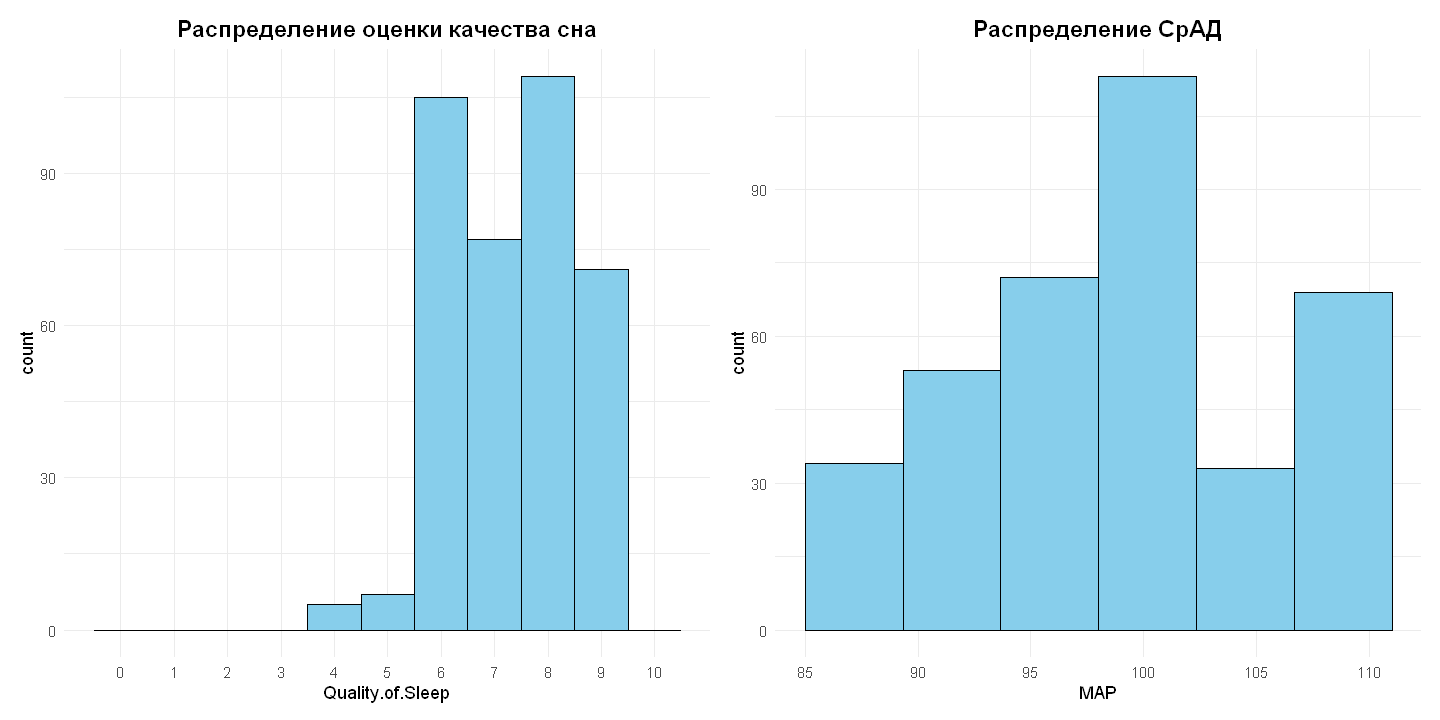

In [80]:
p1 <- ggplot(df, aes(x = Quality.of.Sleep)) + 
  geom_histogram(binwidth = 1, fill = "skyblue", color = "black", boundary = 0.5) +
  theme_minimal() + 
  scale_x_continuous( limits = c(-0.5, 10.5), breaks = 0:10) +
  labs(title = "Распределение оценки качества сна") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    panel.grid.minor.x = element_blank(),
  )
  
# p2 <- ggplot(df, aes(x = MAP)) + 
#   geom_histogram(binwidth = 1, fill = "skyblue", color = "black", boundary = 0.5) +
#   theme_minimal() + 
#   # scale_x_continuous( limits = c(-0.5, 10.5), breaks = 0:10) +
#   labs(title = "Распределение СрАД") +
#   theme(
#     plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
#     panel.grid.minor.x = element_blank(),
#   )

p2 <- ggplot(df, aes(x = MAP)) + 
  geom_histogram(bins = 6, fill = "skyblue", color = "black", boundary = 85) +
  theme_minimal() + 
  scale_x_continuous(breaks = seq(85, 110, length.out = 6)) +
  labs(title = "Распределение СрАД") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    panel.grid.minor.x = element_blank(),
  )

p1 + p2

Теперь мытаемся определить, как давление и качестов сна влияют друг на друга

`geom_smooth()` using formula = 'y ~ x'


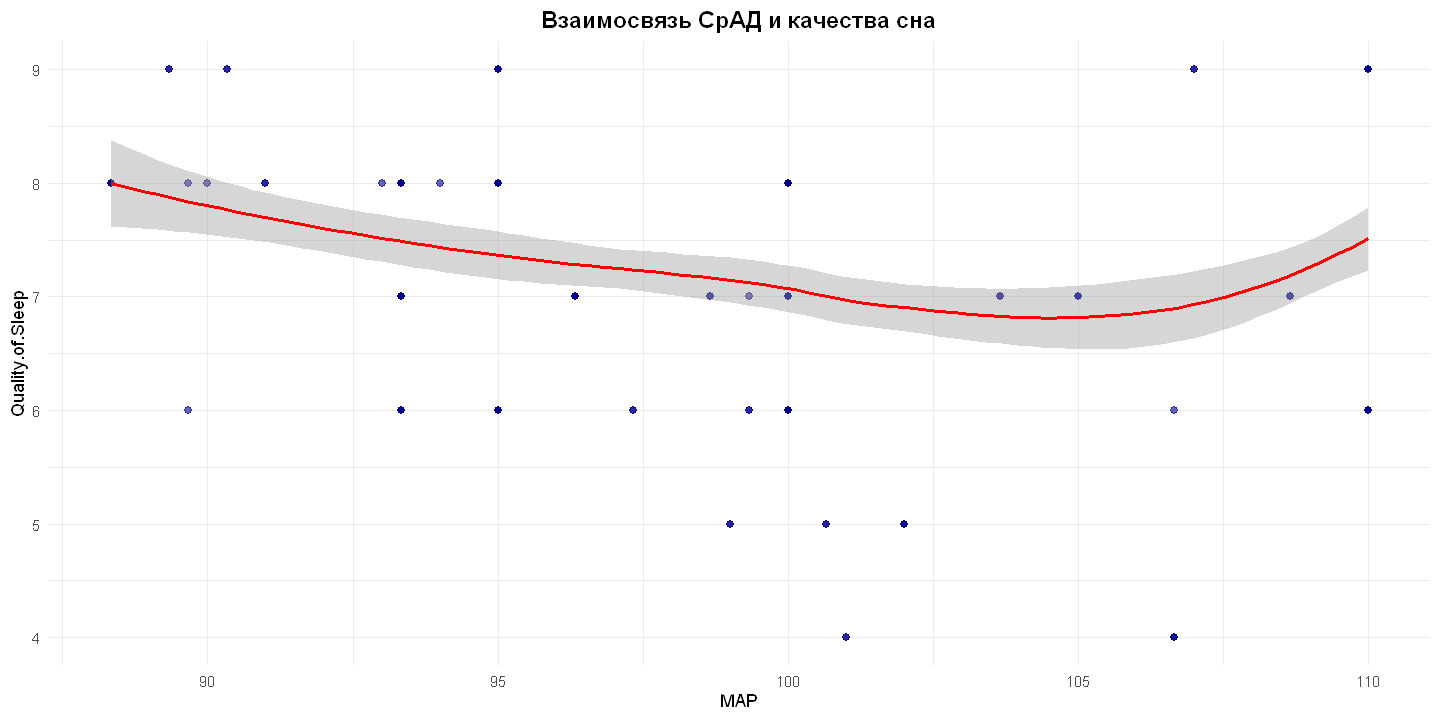

In [81]:
ggplot(df, aes(x = MAP, y = Quality.of.Sleep)) +
  geom_point(color = "darkblue", alpha = 0.6, size = 2) +
  geom_smooth(method = "loess", color = "red", se = TRUE, size = 1) + 
  theme_minimal() +
  labs(title = "Взаимосвязь СрАД и качества сна") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14)
  )

Визуальный анализ методом локальной регрессии (LOESS) указывает на наличие лишь слабой отрицательной тенденции. Нелинейный характер линии и широкий доверительный интервал (серая область) говорят о том, что артериальное давление не является единственным определяющим фактором. Это подтверждает необходимость проведения многофакторного регрессионного анализа и проверки статистических гипотез для выявления скрытых связей

`geom_smooth()` using formula = 'y ~ x'


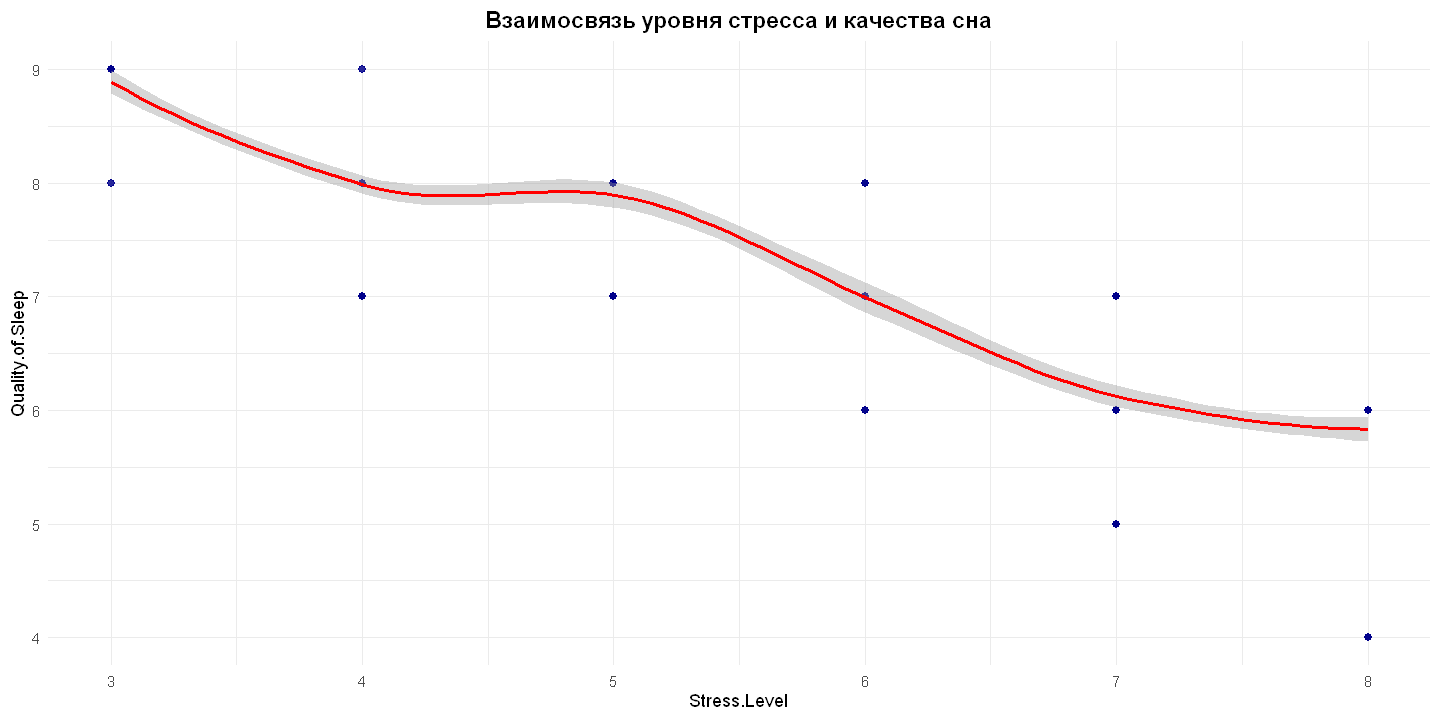

In [82]:
ggplot(df, aes(x = Stress.Level, y = Quality.of.Sleep)) +
  geom_point(color = "darkblue", alpha = 0.6, size = 2) +
  geom_smooth(method = "loess", color = "red", se = TRUE, size = 1) + 
  theme_minimal() +
  labs(title = "Взаимосвязь уровня стресса и качества сна") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14)
  )

Уровень стресса оказывает большее влияние на качество сна, чем давление

`geom_smooth()` using formula = 'y ~ x'


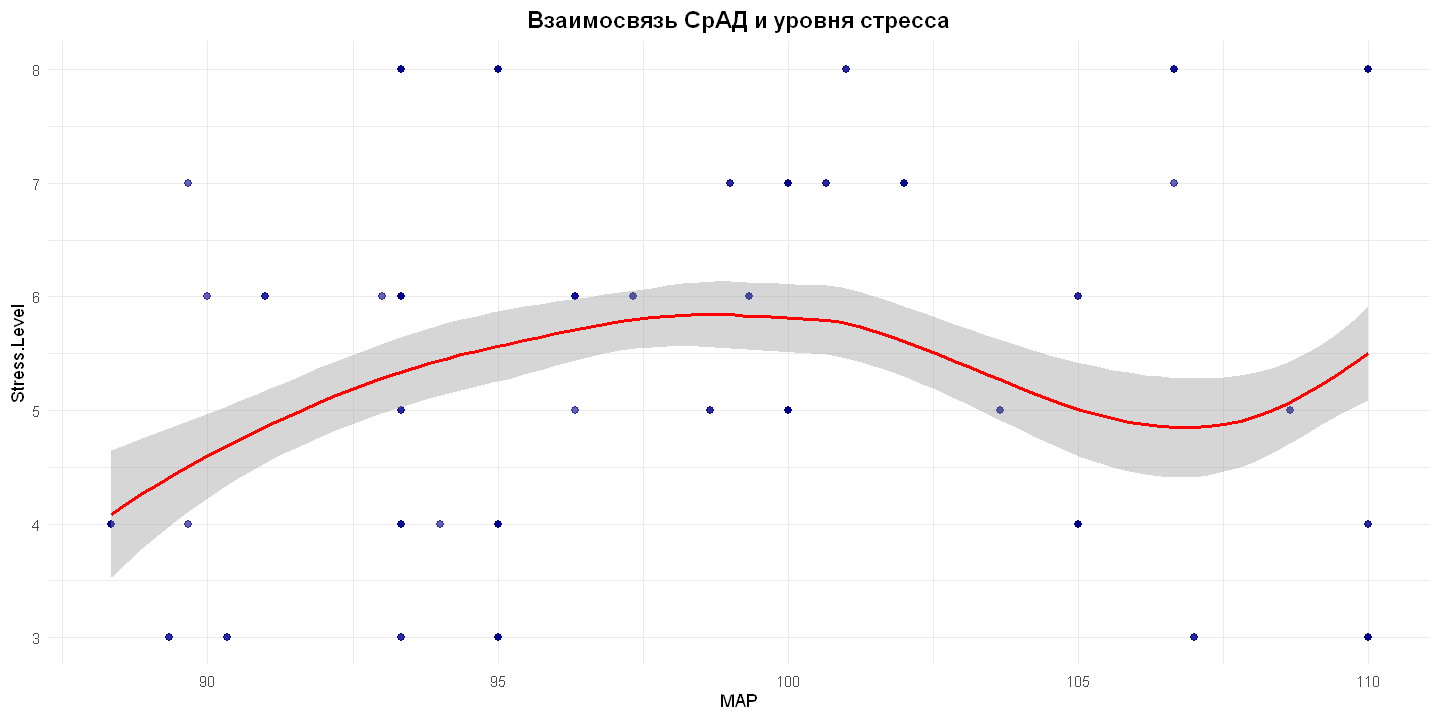

In [83]:
ggplot(df, aes(x = MAP, y = Stress.Level)) +
  geom_point(color = "darkblue", alpha = 0.6, size = 2) +
  geom_smooth(method = "loess", color = "red", se = TRUE, size = 1) + 
  theme_minimal() +
  labs(title = "Взаимосвязь СрАД и уровня стресса") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14)
  )

Отсутствие прямой линейной зависимости между уровнем стресса и артериальным давлением.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


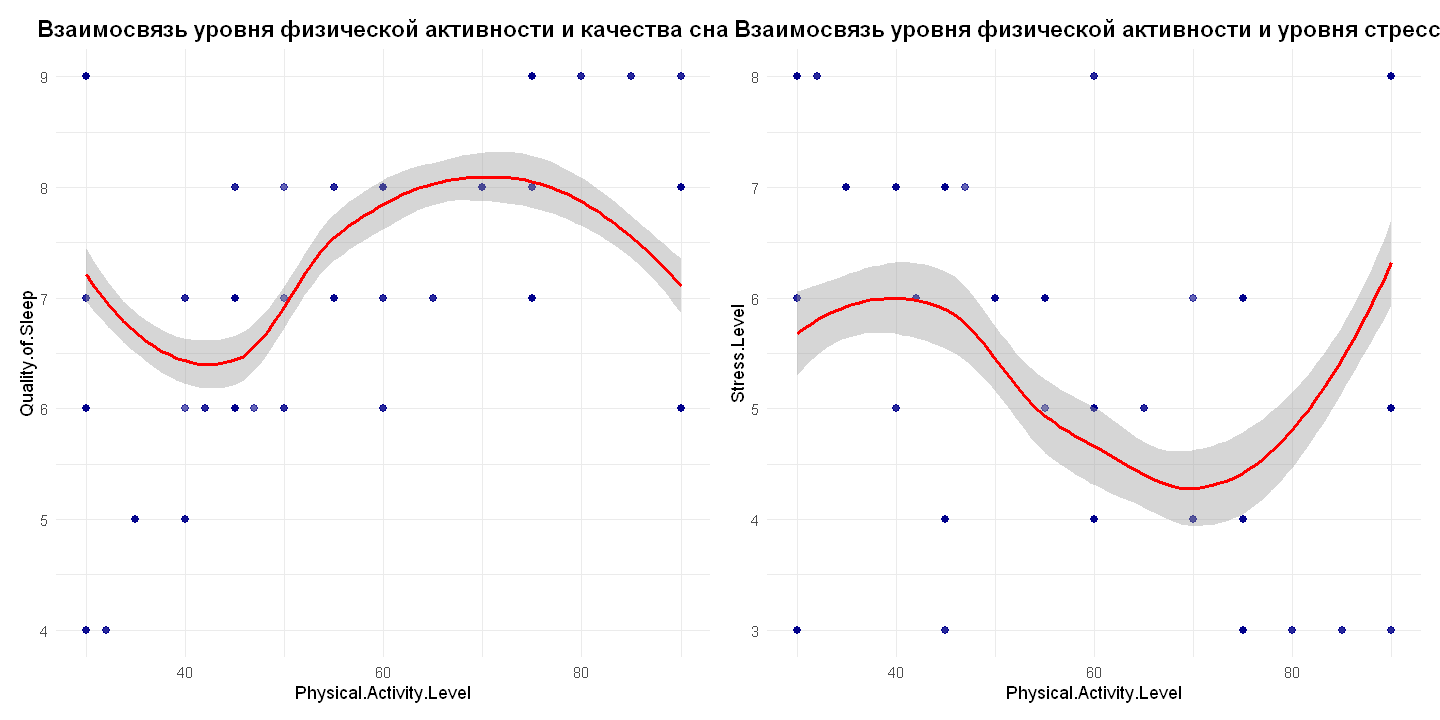

In [84]:
p1 <- ggplot(df, aes(x = Physical.Activity.Level, y = Quality.of.Sleep)) +
  geom_point(color = "darkblue", alpha = 0.6, size = 2) +
  geom_smooth(method = "loess", color = "red", se = TRUE, size = 1) + 
  theme_minimal() +
  labs(title = "Взаимосвязь уровня физической активности и качества сна") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14)
  )

p2 <- ggplot(df, aes(x = Physical.Activity.Level, y = Stress.Level)) +
  geom_point(color = "darkblue", alpha = 0.6, size = 2) +
  geom_smooth(method = "loess", color = "red", se = TRUE, size = 1) + 
  theme_minimal() +
  labs(title = "Взаимосвязь уровня физической активности и уровня стресса") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14)
  )

p1 + p2

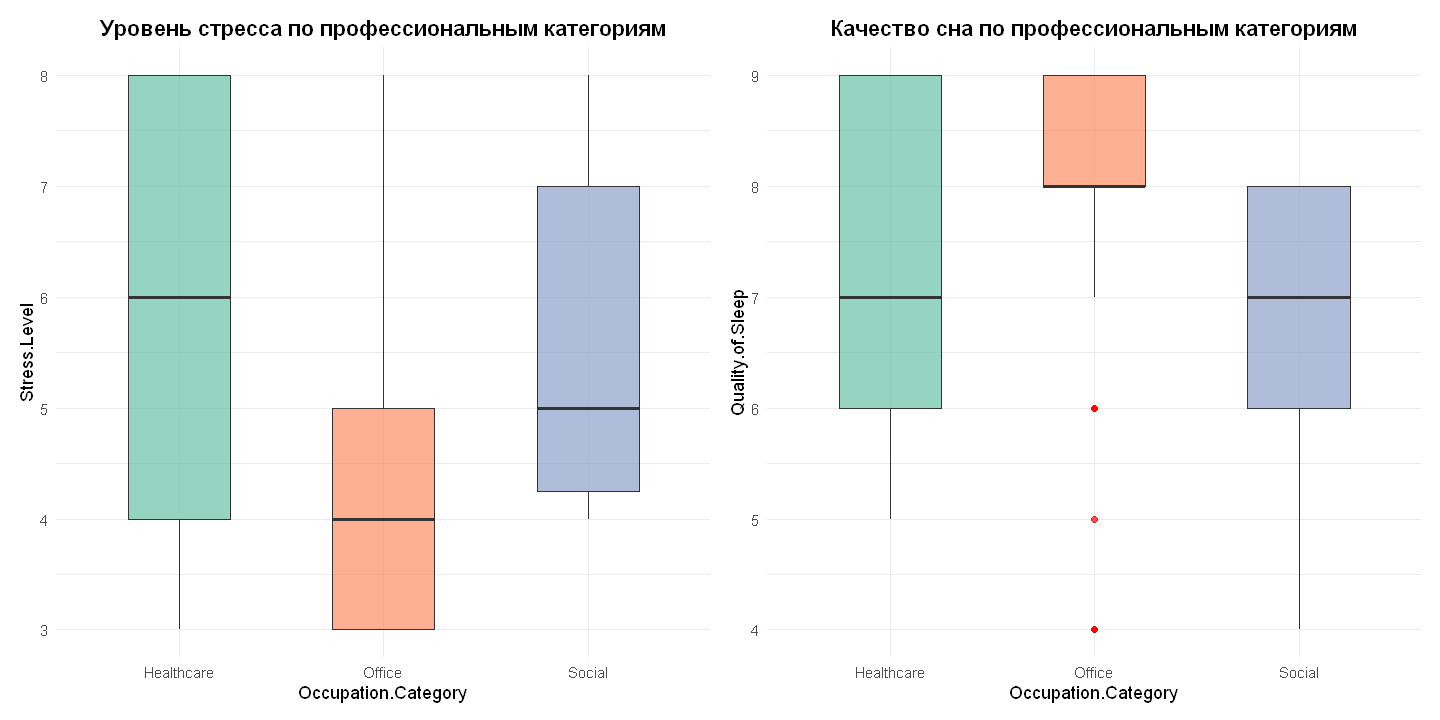

In [85]:
p1 <- ggplot(df, aes(x = Occupation.Category, y = Stress.Level, fill = Occupation.Category)) +
  geom_boxplot(alpha = 0.7, width = 0.5, outlier.colour = "red") +
  scale_fill_brewer(palette = "Set2") + 
  theme_minimal() +
  labs(title = "Уровень стресса по профессиональным категориям") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "none" 
  )

p2 <- ggplot(df, aes(x = Occupation.Category, y = Quality.of.Sleep, fill = Occupation.Category)) +
  geom_boxplot(alpha = 0.7, width = 0.5, outlier.colour = "red") +
  scale_fill_brewer(palette = "Set2") + 
  theme_minimal() +
  labs(title = "Качество сна по профессиональным категориям") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "none" 
  )

p1 + p2

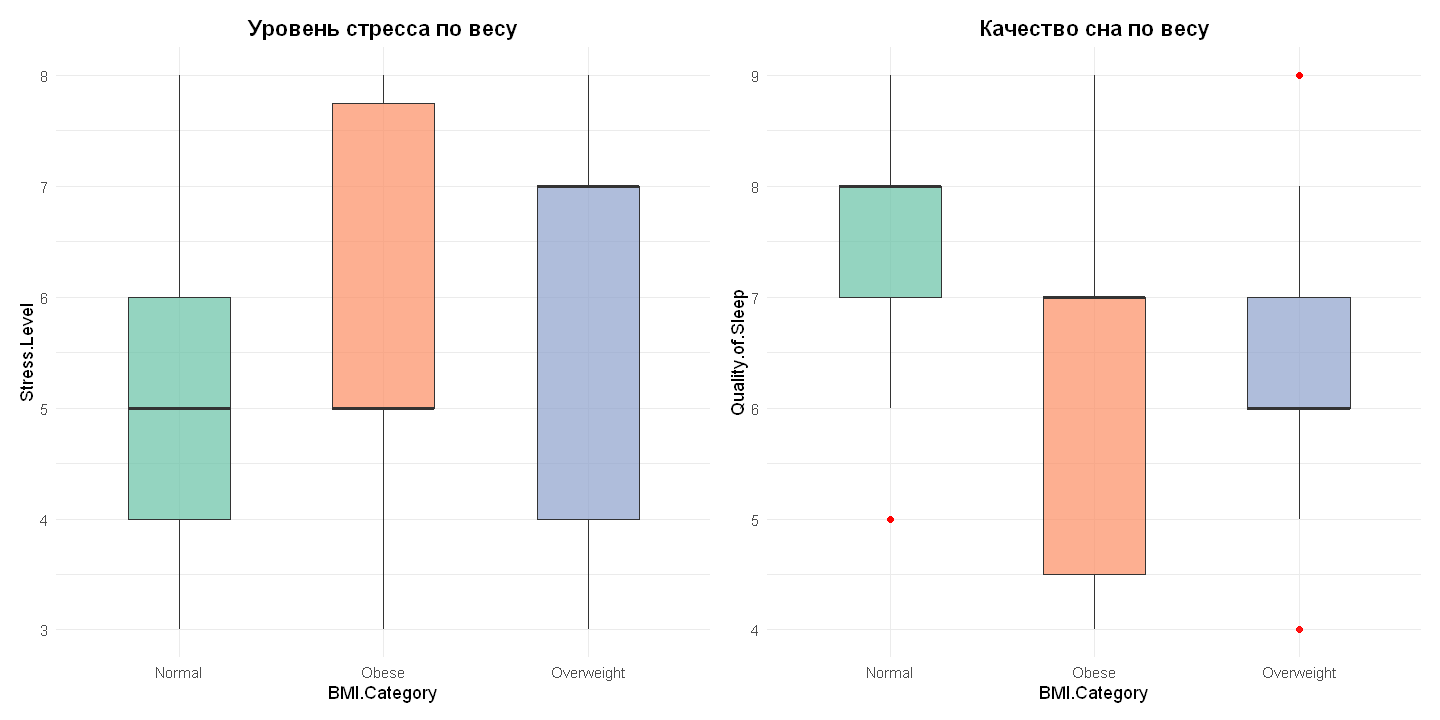

In [86]:
p1 <- ggplot(df, aes(x = BMI.Category, y = Stress.Level, fill = BMI.Category)) +
  geom_boxplot(alpha = 0.7, width = 0.5, outlier.colour = "red") +
  scale_fill_brewer(palette = "Set2") + 
  theme_minimal() +
  labs(title = "Уровень стресса по весу") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "none" 
  )

p2 <- ggplot(df, aes(x = BMI.Category, y = Quality.of.Sleep, fill = BMI.Category)) +
  geom_boxplot(alpha = 0.7, width = 0.5, outlier.colour = "red") +
  scale_fill_brewer(palette = "Set2") + 
  theme_minimal() +
  labs(title = "Качество сна по весу") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "none" 
  )

p1 + p2

### 2.2.2. Корреляционный анализ (корреляционные матрицы, значимость корреляции)

In [87]:
number_column <- c('Quality.of.Sleep', 'Age', 'Sleep.Duration', 'Physical.Activity.Level', 'Stress.Level', 'Daily.Steps', 'Heart.Rate', 'Systolic', 'Diastolic', 'MAP')

cor_matrix <- cor(df[number_column], use = "complete.obs")
round(cor_matrix, 2)

,Quality.of.Sleep,Age,Sleep.Duration,Physical.Activity.Level,Stress.Level,Daily.Steps,Heart.Rate,Systolic,Diastolic,MAP
Quality.of.Sleep,1.00,0.47,0.88,0.19,-0.90,0.02,-0.66,-0.12,-0.11,-0.12
Age,0.47,1.00,0.34,0.18,-0.42,0.06,-0.23,0.61,0.59,0.60
Sleep.Duration,0.88,0.34,1.00,0.21,-0.81,-0.04,-0.52,-0.18,-0.17,-0.17
Physical.Activity.Level,0.19,0.18,0.21,1.00,-0.03,0.77,0.14,0.27,0.38,0.34
Stress.Level,-0.90,-0.42,-0.81,-0.03,1.00,0.19,0.67,0.10,0.09,0.10
Daily.Steps,0.02,0.06,-0.04,0.77,0.19,1.00,-0.03,0.10,0.24,0.19
Heart.Rate,-0.66,-0.23,-0.52,0.14,0.67,-0.03,1.00,0.29,0.27,0.28
Systolic,-0.12,0.61,-0.18,0.27,0.10,0.10,0.29,1.00,0.97,0.99
Diastolic,-0.11,0.59,-0.17,0.38,0.09,0.24,0.27,0.97,1.00,1.00
MAP,-0.12,0.60,-0.17,0.34,0.10,0.19,0.28,0.99,1.00,1.00


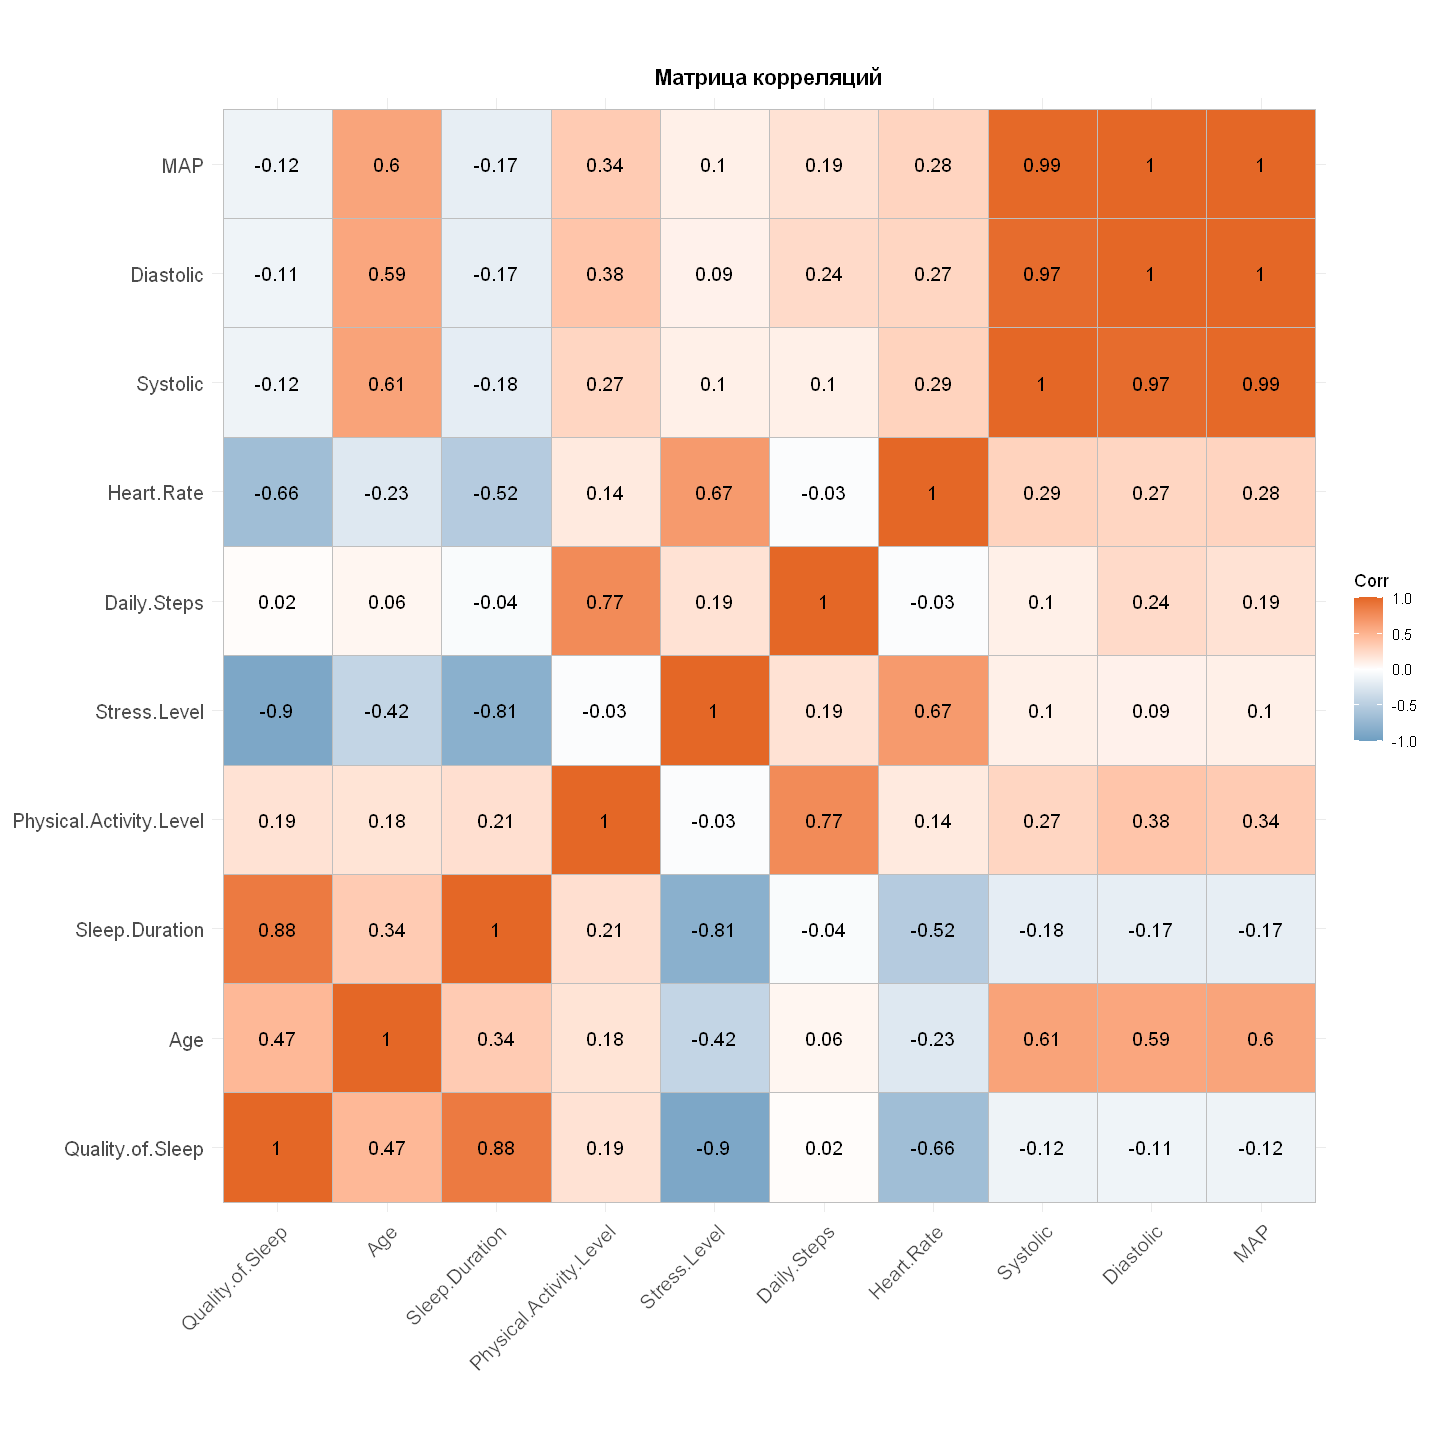

In [88]:
options(repr.plot.width = 12, repr.plot.height = 12)

ggcorrplot(cor_matrix, lab = TRUE, colors = c("#6D9EC1", "white", "#E46726")) +
        labs(title = 'Матрица корреляций') +
        theme(
            plot.title = element_text(hjust = 0.5, face = "bold"),
        )

### 2.2.3. Выявление выбросов и трендов (поиск аномалий, анализ временных рядов).

In [89]:
check_cols <- c("Daily.Steps", "Heart.Rate", "Systolic", 'Diastolic', "Physical.Activity.Level", 'MAP')
lapply(df[check_cols], function(x) boxplot.stats(x)$out)

$Daily.Steps
integer(0)

$Heart.Rate
 [1] 85 85 85 82 80 80 81 81 84 84 80 83 83 86 86

$Systolic
numeric(0)

$Diastolic
numeric(0)

$Physical.Activity.Level
integer(0)

$MAP
numeric(0)

Выбросы только в HeartRte (пульс). Сами значения находятся в пределах медицинской нормы: \
ниже 60 — брадикардия (у спортсменов норма, сердце качает кровь лучше) \
60-80 — норма \
90-100 — тахикардия (стресс, болезни, плохая физ форма)

Поэтому за выбросы это не счиатем

## 2.3. Применение методов статистического анализа

### 2.3.1. Описательная статистика (средние, дисперсия, стандартное отклонение).

In [90]:
stats_table <- data.frame()

for (col in number_column) {
    mn = mean(df[[col]], na.rm = TRUE)
    md = median(df[[col]], na.rm = TRUE)
    std =sd(df[[col]], na.rm = TRUE)
    d = var(df[[col]], na.rm = TRUE)

    new_row <- data.frame(
            Признак = col,
            Среднее = round(mn, 2),
            Медиана = round(md, 2),
            Станд_откл = round(std, 2),
            Дисперсия = round(d, 2)
        )

    stats_table <- rbind(stats_table, new_row)
}

print(stats_table)

                   Признак Среднее Медиана Станд_откл  Дисперсия
1         Quality.of.Sleep    7.31     7.0       1.20       1.43
2                      Age   42.18    43.0       8.67      75.22
3           Sleep.Duration    7.13     7.2       0.80       0.63
4  Physical.Activity.Level   59.17    60.0      20.83     433.92
5             Stress.Level    5.39     5.0       1.77       3.15
6              Daily.Steps 6816.84  7000.0    1617.92 2617651.14
7               Heart.Rate   70.17    70.0       4.14      17.10
8                 Systolic  128.55   130.0       7.75      60.03
9                Diastolic   84.65    85.0       6.16      37.97
10                     MAP   99.28   100.0       6.65      44.20


In [91]:
table(df$Gender) # Выборка сбалансирована по полу


Female   Male 
   185    189 

### 2.3.2. Проверка гипотез (t-тест, ANOVA, хи-квадрат).

In [92]:
options(repr.plot.width = 12, repr.plot.height = 6)

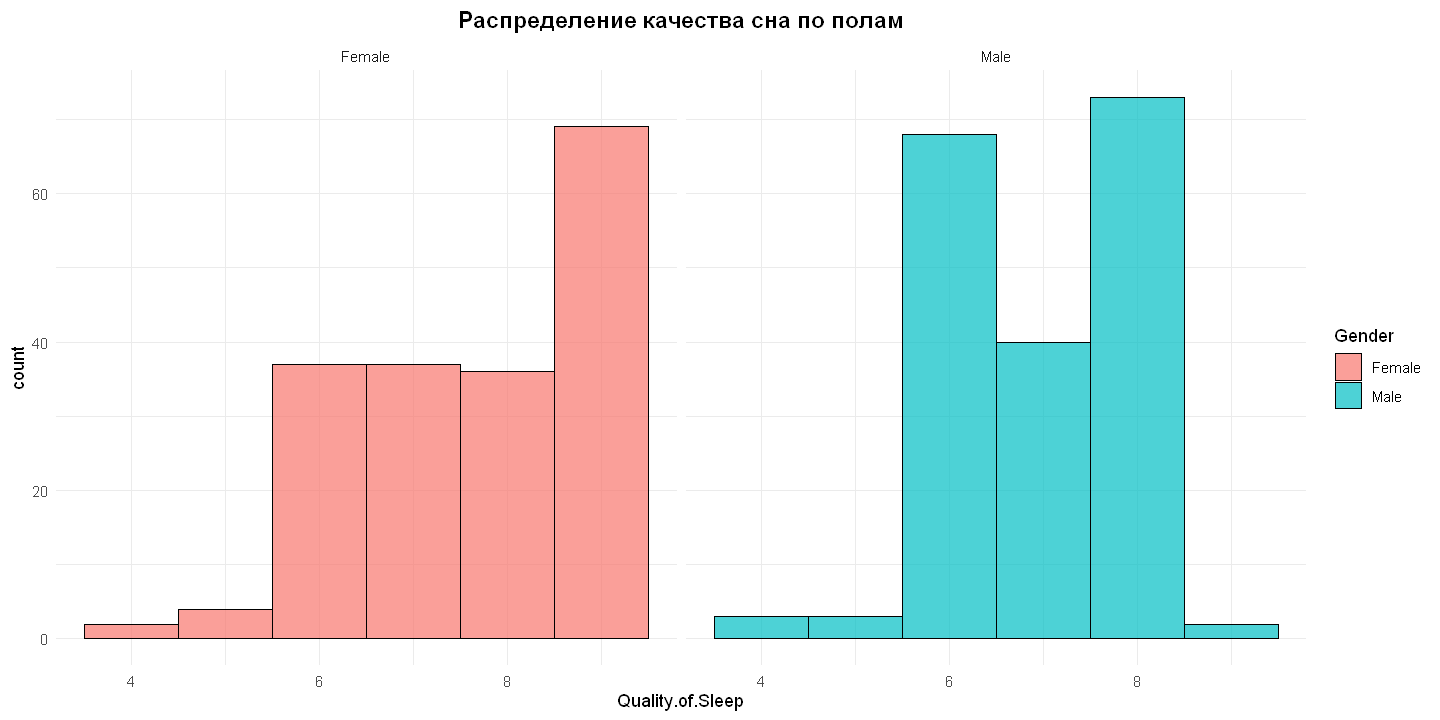

In [93]:
ggplot(df, aes(x = Quality.of.Sleep, fill = Gender)) +
  geom_histogram(binwidth = 1, color = "black", alpha = 0.7) +
  facet_wrap(~Gender) + 
  theme_minimal() +
  labs(title = "Распределение качества сна по полам") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
  )

# распределение не нормальное. Используем U-критерий Манна-Уитни

**Качество сна по гендеру** \
Нулевая гипотеза: Среднее качество сна у мужчин и женщин не имеет статистически значимых различий. \
Альтернативная гипотеза: Среднее качество сна у женщин статистически значимо выше (или отличается), чем у мужчин.

In [94]:
# U-критерий Манна-Уитни
t_result <- wilcox.test(Quality.of.Sleep ~ Gender, data = df)
print(t_result)


	Wilcoxon rank sum test with continuity correction

data:  Quality.of.Sleep by Gender
W = 23369, p-value = 6.048e-09
alternative hypothesis: true location shift is not equal to 0



Альтернативная гипотеза подтвердилась. (Предположительно женщины спят лучше мужчин)

**Профессии по гендеру** \
Сам пол влиять на качество сна не может. Возможно дело в профессиональной сфере. \
Нулевая гипотеза: Пол и выбор профессиональной категории независимы друг от друга (распределение мужчин и женщин во всех профессиях примерно одинаковое). \
Альтернативная гипотеза: между полом и категорией профессии существует статистически значимая связь (наблюдается профессиональная сегрегация).

In [95]:
t_result <- chisq.test(table(df$Gender, df$Occupation.Category))
print(t_result)


	Pearson's Chi-squared test

data:  table(df$Gender, df$Occupation.Category)
X-squared = 29.555, df = 2, p-value = 3.822e-07



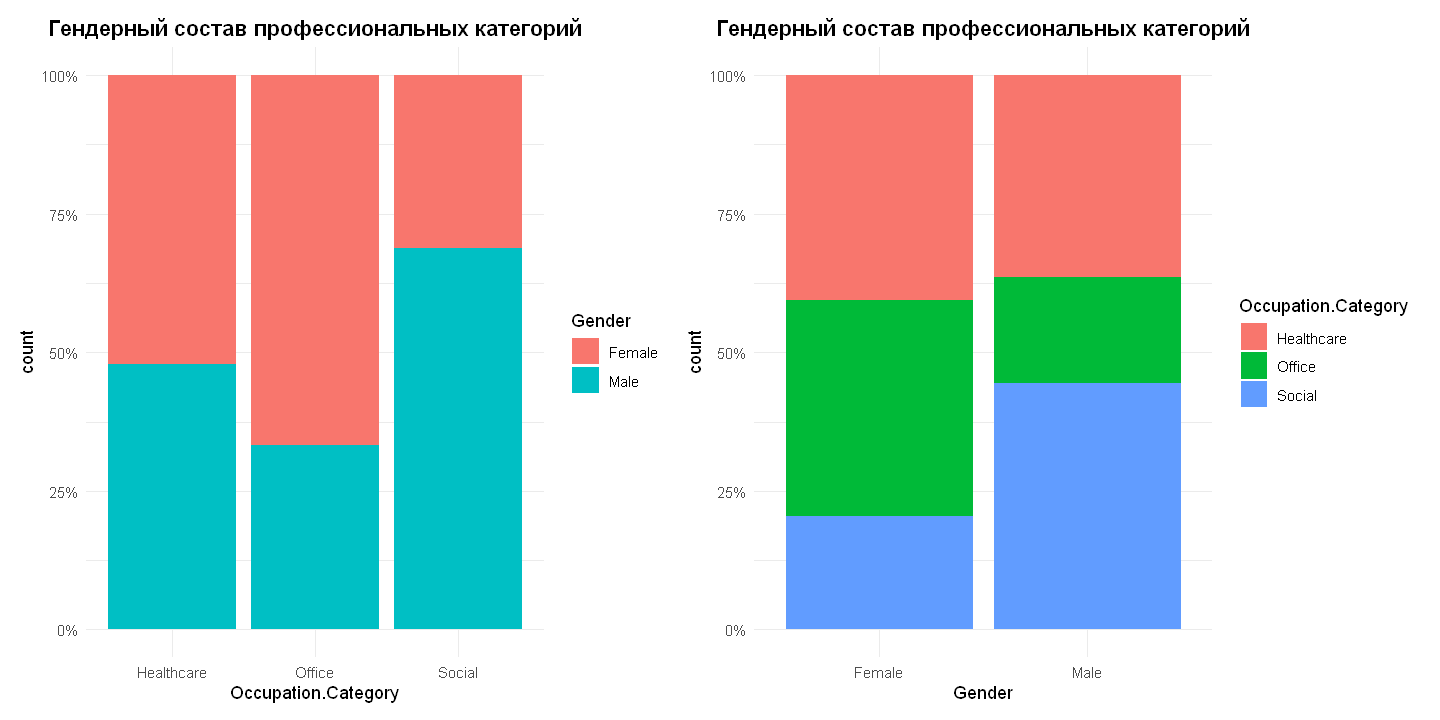

In [96]:
p1 <- ggplot(df, aes(x = Occupation.Category, fill = Gender)) +
  geom_bar(position = "fill") + 
  scale_y_continuous(labels = scales::percent) +
  theme_minimal() +
  labs(title = "Гендерный состав профессиональных категорий") +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))

p2 <- ggplot(df, aes(x = Gender, fill = Occupation.Category)) +
  geom_bar(position = "fill") + 
  scale_y_continuous(labels = scales::percent) +
  theme_minimal() +
  labs(title = "Гендерный состав профессиональных категорий") +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))

p1 + p2

Т.к выборка сбалансирована по полу, можно сделать вывод, что женщины спят лучше, так как преимущественно работают в офисе. Следовательно, дело в профессиональной сфере.

**Профессии по стрессу** \
Нулевая гипотеза: Уровень стресса одинаков для всех профессиональных категорий. \
Альтернативная гиптеза: Тип профессиональной деятельности значимо влияет на уровень стресса.


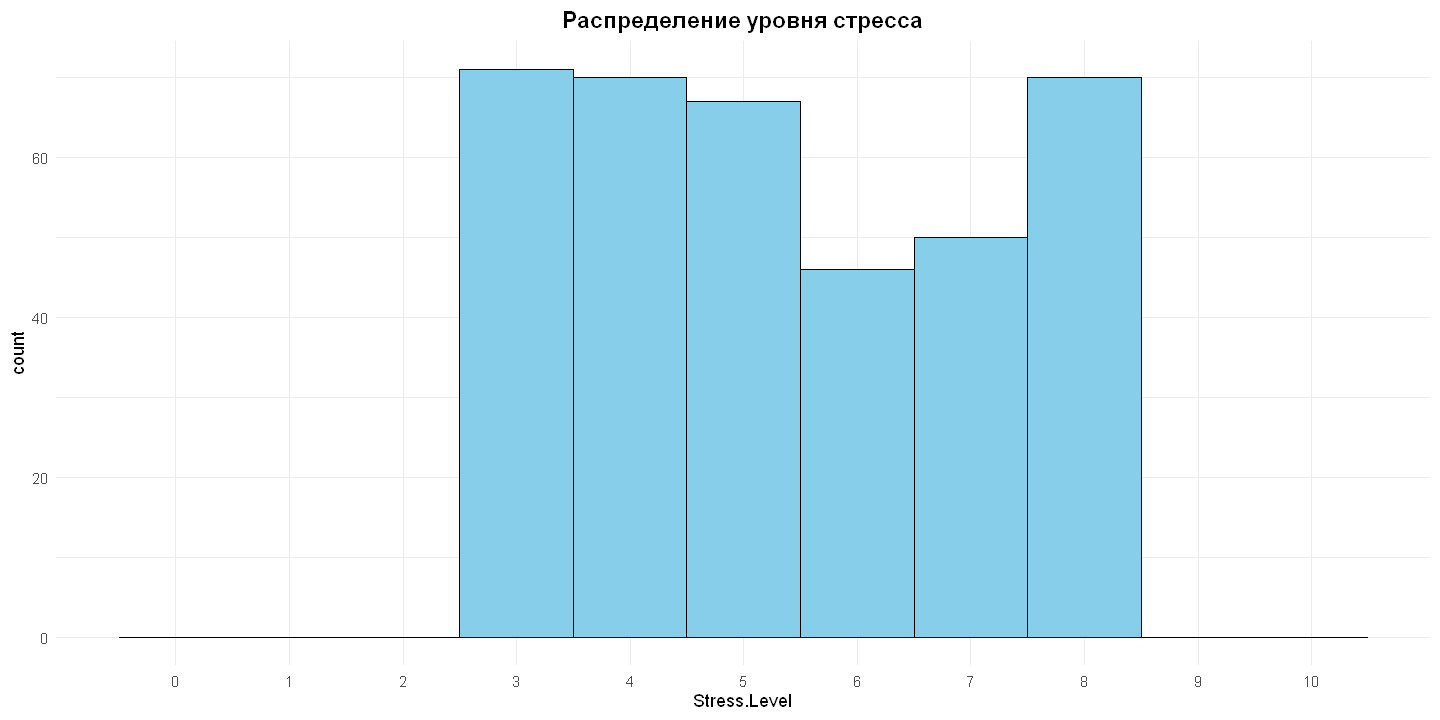

In [97]:
ggplot(df, aes(x = Stress.Level)) + 
  geom_histogram(binwidth = 1, fill = "skyblue", color = "black", boundary = 0.5) +
  theme_minimal() + 
  scale_x_continuous( limits = c(-0.5, 10.5), breaks = 0:10) +
  labs(title = "Распределение уровня стресса") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    panel.grid.minor.x = element_blank(),
  )

Распределение уровня стресса и качества сна не нормальное. Следовательно, используем тест Краскела-Уоллиса.

In [98]:
kruskal.test(Stress.Level ~ Occupation.Category, data = df)


	Kruskal-Wallis rank sum test

data:  Stress.Level by Occupation.Category
Kruskal-Wallis chi-squared = 62.364, df = 2, p-value = 2.869e-14


Профессиональная деятельность оказывает определяющее влияние на уровень психологического стресса. \
Графики уже построены.

**Влияние веса на качессвто сна** \
Нулевая гипотеза: Средние ранги качества сна одинаковы для всех категорий ИМТ. \
Альтернативная гипотеза: Категория ИМТ значимо влияет на качество сна.

In [99]:
# Кракер-Уоллис, т.к неравномерное распределение

kruskal.test(Quality.of.Sleep ~ BMI.Category, data = df)



	Kruskal-Wallis rank sum test

data:  Quality.of.Sleep by BMI.Category
Kruskal-Wallis chi-squared = 37.895, df = 2, p-value = 5.904e-09


Альтернативная гипотеза подтверждена. \
Чем больше лишнего веса, тем бльше стресса, тем хуже качество сна. \
Графики уже есть.

**Влияние профессии на давление** \
Нулевая гипотеза — Среднее артериальное давление не зависит от профессиональной категории. \
Альтернативная гипотеза — Профессиональная деятельность значимо влияет на уровень системного давления.

In [100]:
kruskal.test(MAP ~ Occupation.Category, data = df)


	Kruskal-Wallis rank sum test

data:  MAP by Occupation.Category
Kruskal-Wallis chi-squared = 72.252, df = 2, p-value < 2.2e-16


Альтернативная гипотеза подтверждена. \
Офисные работники меньше испытывают стресс и лучше спят.  \
Графики уже есть.

**Продолжительность сна и профессия** \
Нулевая гипотеза —  Продолжительность сна во всех профессиональных группах одинакова. \
Альтернативная гипотеза — Существуют значимые различия в количестве часов сна между профессиями.

In [101]:
kruskal.test(Sleep.Duration ~ Occupation.Category, data = df)


	Kruskal-Wallis rank sum test

data:  Sleep.Duration by Occupation.Category
Kruskal-Wallis chi-squared = 42.707, df = 2, p-value = 5.324e-10


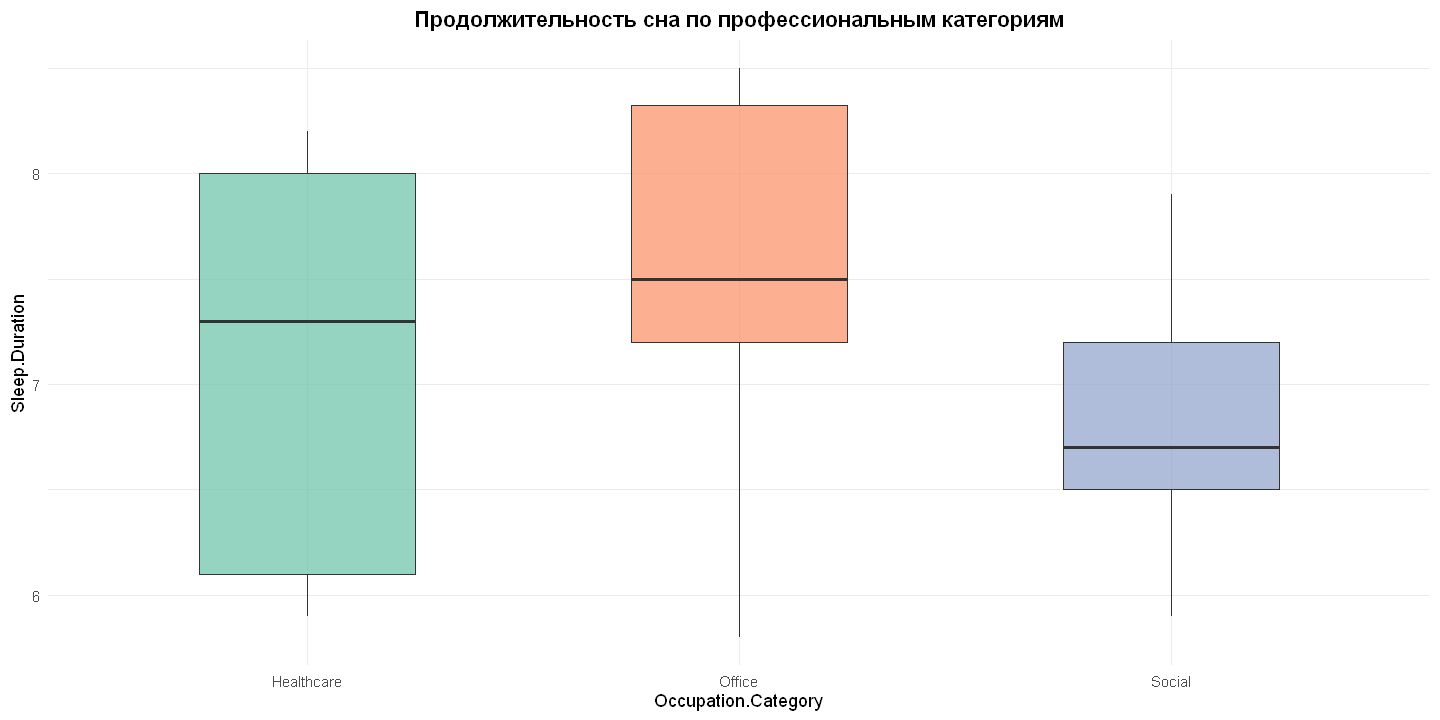

In [102]:
ggplot(df, aes(x = Occupation.Category, y = Sleep.Duration, fill = Occupation.Category)) +
  geom_boxplot(alpha = 0.7, width = 0.5, outlier.colour = "red") +
  scale_fill_brewer(palette = "Set2") + 
  theme_minimal() +
  labs(title = "Продолжительность сна по профессиональным категориям") +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "none" 
  )

Альтернативная гипотеза подтверждена.

### 2.3.3. Регрессионный анализ (модели прогнозирования).

In [113]:
linreg <- lm(Quality.of.Sleep ~ Stress.Level + MAP + Sleep.Duration + Age + BMI.Category, data = df)
summary(linreg)
vif(linreg)


Call:
lm(formula = Quality.of.Sleep ~ Stress.Level + MAP + Sleep.Duration + 
    Age + BMI.Category, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.33178 -0.10849  0.02672  0.17799  1.05337 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)             4.467061   0.487697   9.160  < 2e-16 ***
Stress.Level           -0.361462   0.017349 -20.834  < 2e-16 ***
MAP                     0.009346   0.004492   2.080   0.0382 *  
Sleep.Duration          0.344435   0.043909   7.844 4.80e-14 ***
Age                     0.041478   0.003490  11.886  < 2e-16 ***
BMI.CategoryObese      -0.975818   0.117269  -8.321 1.73e-15 ***
BMI.CategoryOverweight -0.798039   0.065177 -12.244  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.3228 on 367 degrees of freedom
Multiple R-squared:  0.9284,	Adjusted R-squared:  0.9273 
F-statistic: 793.6 on 6 and 367 DF,  p-value: < 2.2e-16


,GVIF,Df,GVIF^(1/(2*Df))
Stress.Level,3.393027,1,1.842017
MAP,3.192991,1,1.786894
Sleep.Duration,4.369297,1,2.090286
Age,3.279217,1,1.810861
BMI.Category,4.067354,2,1.420130


VIF — для проверки на мультиколлинеарность. Этот коэффициент показывает, насколько факторы «дублируют» друг друга. Если два фактора слишком связаны, модель не сможет определить истинный вклад каждого. Значение VIF выше 5 считается критическим, выше 10 — недопустимым.
По этой причине в модель не были включены категории профессий и уровень физической активности.

## 2.4. Машинное обучение в анализе данных (по необходимости)

### 2.4.1. Классификация данных (логистическая регрессия, KNN).

In [118]:
lda_model <- lda(Sleep.Disorder ~ Stress.Level + MAP + Age + Daily.Steps + BMI.Category, data = df)
lda_model

Call:
lda(Sleep.Disorder ~ Stress.Level + MAP + Age + Daily.Steps + 
    BMI.Category, data = df)

Prior probabilities of groups:
   Insomnia        None Sleep Apnea 
  0.2058824   0.5855615   0.2085561 

Group means:
            Stress.Level       MAP      Age Daily.Steps BMI.CategoryObese
Insomnia        5.870130 101.91792 43.51948    5901.299        0.05194805
None            5.114155  95.34731 39.03653    6852.968        0.00000000
Sleep Apnea     5.666667 107.73513 49.70513    7619.231        0.07692308
            BMI.CategoryOverweight
Insomnia                0.83116883
None                    0.08675799
Sleep Apnea             0.83333333

Coefficients of linear discriminants:
                                 LD1           LD2
Stress.Level           -1.118623e-01  0.0122618503
MAP                    -8.614101e-02  0.1111131411
Age                    -1.869025e-02  0.0558510513
Daily.Steps             1.198031e-05  0.0004461544
BMI.CategoryObese      -2.994360e+00  0.4056072201
B

Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
"Probable convergence failure"


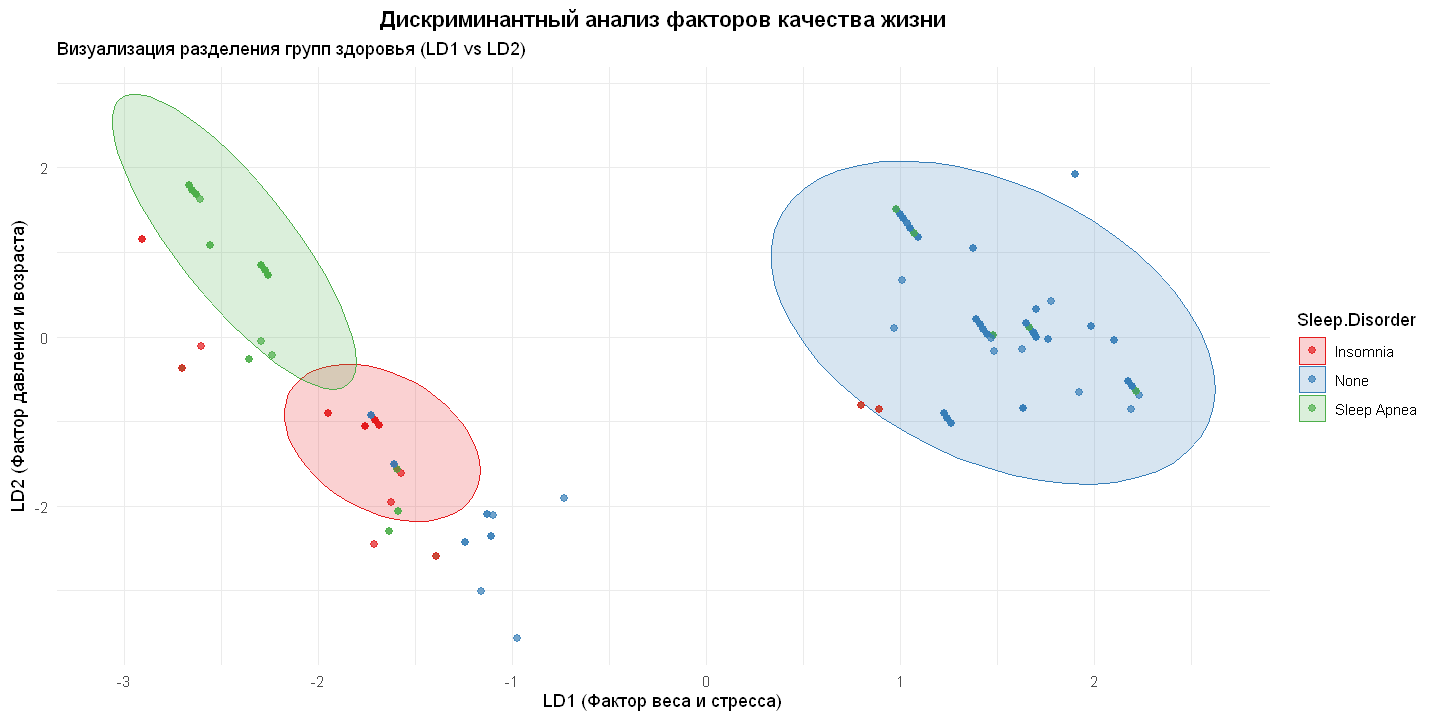

In [120]:
lda_predict <- predict(lda_model)
plot_data <- data.frame(df, lda_predict$x)


ggplot(plot_data, aes(x = LD1, y = LD2, color = Sleep.Disorder, fill = Sleep.Disorder)) +
  stat_ellipse(geom = "polygon", alpha = 0.2) + 
  geom_point(size = 2, alpha = 0.7) +
  theme_minimal() +
  scale_color_brewer(palette = "Set1") +
  scale_fill_brewer(palette = "Set1") +
  labs(title = "Дискриминантный анализ факторов качества жизни",
       subtitle = "Визуализация разделения групп здоровья (LD1 vs LD2)",
       x = "LD1 (Фактор веса и стресса)", 
       y = "LD2 (Фактор давления и возраста)") +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))

### 2.4.2. Кластеризация (K-means, иерархическая кластеризация).

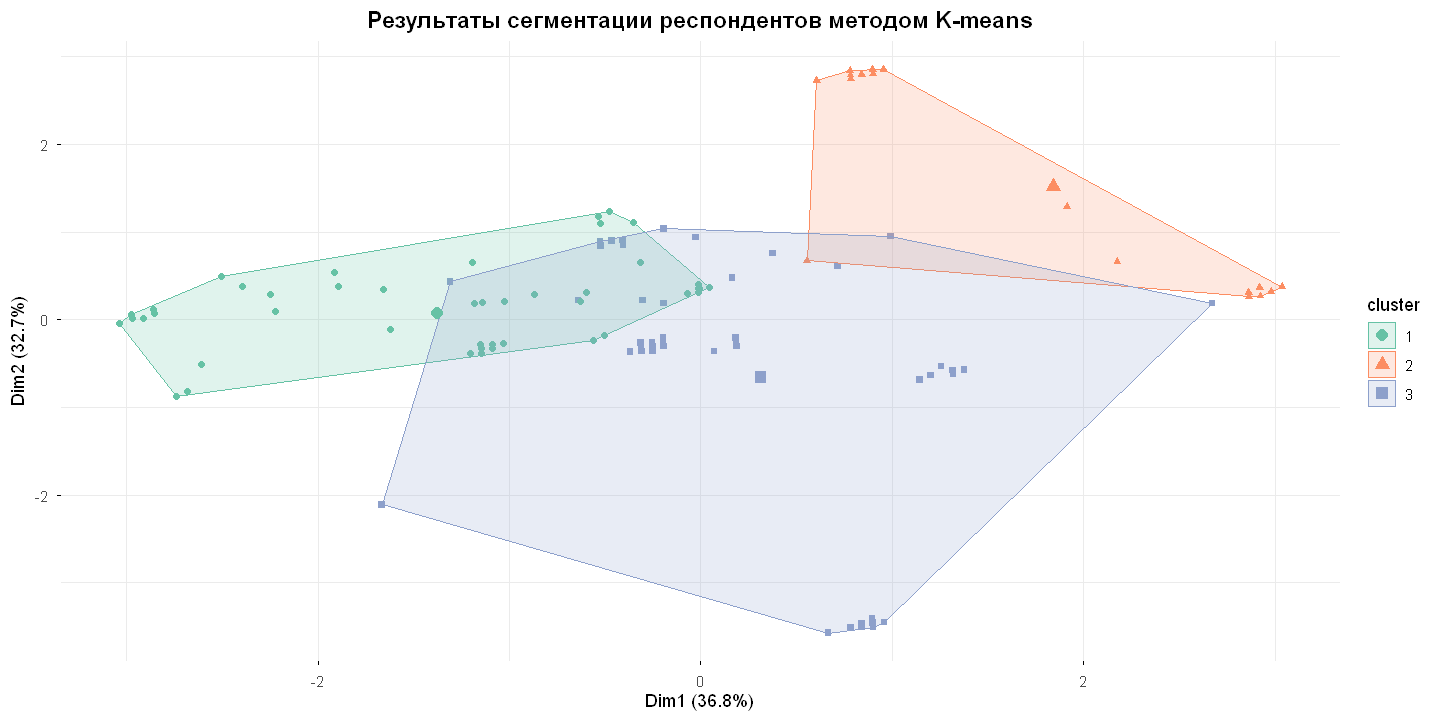

In [126]:
cluster_cols <- c("Stress.Level", "MAP", "Age", "Daily.Steps", "Sleep.Duration", "Physical.Activity.Level")
cluster_data <- df[, cluster_cols]

cluster_scaled <- scale(cluster_data)

set.seed(123)
km_res <- kmeans(cluster_scaled, centers = 3, nstart = 25)

fviz_cluster(km_res, data = cluster_scaled,
             palette = "Set2",
             geom = "point",
             ellipse.type = "convex", 
             ggtheme = theme_minimal(),
             main = "Результаты сегментации респондентов методом K-means") +
            theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 14)
            )
             


In [129]:
table(Кластер = km_res$cluster, Диагноз = df$Sleep.Disorder)

       Диагноз
Кластер Insomnia None Sleep Apnea
      1       68   51          13
      2        3   34          32
      3        6  134          33